In [1]:
# Project setup

from pathlib import Path
import sys
import os

PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python path updated.")

Project root: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM
Python path updated.


In [2]:
# Environment sanity checks

import platform
import torch

print("Python version:", platform.python_version())
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    props = torch.cuda.get_device_properties(torch.cuda.current_device())
    print("Total GPU memory (GB):", round(props.total_memory / (1024**3), 2))
else:
    print("No CUDA device visible.")

Python version: 3.9.18
Torch version: 2.5.1+cu124
CUDA available: True
CUDA device count: 1
Current device: 0
Device name: NVIDIA A100-SXM4-40GB
Total GPU memory (GB): 39.49


In [3]:
# Import project modules

import json
import math
import time
import pandas as pd
import matplotlib.pyplot as plt

from config import CONFIG, RAW_RESULTS_DIR, LOGS_DIR
from runner import run_single_benchmark, run_single_benchmark_by_name
from workloads import build_runtime_workload_by_name
from modes import (
    build_runtime_mode_by_name,
    get_all_runtime_modes,
    get_default_hybrid_modes,
)
from benchmark_modes import (
    run_full_benchmark,
    save_results_json,
    save_results_csv,
    save_summary_csv,
    build_aggregate_rows,
    build_comparison_rows,
    save_aggregate_csv,
)
from reporter import generate_full_report

print("Imports successful.")

Imports successful.


In [4]:
# Resolve both standard and hybrid modes safely

def resolve_runtime_mode(mode_name: str):
    """
    Resolve a runtime mode by name.
    First try the normal registry, then fall back to default hybrid registry.
    """
    try:
        return build_runtime_mode_by_name(mode_name)
    except Exception:
        hybrid_map = {mode.name: mode for mode in get_default_hybrid_modes()}
        if mode_name in hybrid_map:
            return hybrid_map[mode_name]
        raise

def list_all_notebook_modes():
    standard = get_all_runtime_modes(enabled_only=True)
    hybrids = get_default_hybrid_modes()
    all_modes = standard + [m for m in hybrids if m.name not in {x.name for x in standard}]
    return all_modes

all_modes = list_all_notebook_modes()
print("All notebook-visible modes:")
for m in all_modes:
    print(f" - {m.name}")

All notebook-visible modes:
 - fp16_baseline
 - int8_quant
 - awq_4bit
 - gptq_4bit
 - speculative_decoding
 - kv_cache_compression
 - prefix_caching
 - chunked_prefill
 - continuous_batching
 - cuda_graphs
 - gptq_plus_prefix_caching
 - int8_plus_continuous_batching


In [5]:
# Confirm your chosen modes resolve

MAIN_MODES = [
    "fp16_baseline",
    "gptq_4bit",
    "int8_quant",
    "speculative_decoding",
    "gptq_plus_prefix_caching",
    "int8_plus_continuous_batching",
]

resolved_rows = []
for mode_name in MAIN_MODES:
    mode = resolve_runtime_mode(mode_name)
    resolved_rows.append({
        "mode_name": mode.name,
        "backend": mode.backend,
        "quantization": mode.quantization,
        "prefix_caching": mode.prefix_caching,
        "continuous_batching": mode.continuous_batching,
        "speculative_decoding": mode.speculative_decoding,
        "primary_phase": mode.primary_phase,
        "notes": mode.notes,
    })

pd.DataFrame(resolved_rows)

,mode_name,backend,quantization,prefix_caching,continuous_batching,speculative_decoding,primary_phase,notes
0,fp16_baseline,vllm,None,False,False,False,both,standard mode
1,gptq_4bit,vllm,gptq,False,False,False,decode,quantization=gptq
2,int8_quant,vllm,compressed-tensors,False,False,False,decode,quantization=compressed-tensors
3,speculative_decoding,vllm,None,False,False,True,decode,speculative decoding enabled
4,gptq_plus_prefix_caching,vllm,gptq,True,False,False,both,quantization=gptq; prefix caching enabled
5,int8_plus_continuous_batching,vllm,compressed-tensors,False,True,False,decode,quantization=compressed-tensors; continuous ba...


In [6]:
# Run unit tests

import subprocess
import sys

cmd = [sys.executable, "-m", "unittest", "test_benchmarks.py", "-v"]
completed = subprocess.run(cmd, capture_output=True, text=True)

print("RETURN CODE:", completed.returncode)
print("\nSTDOUT:\n")
print(completed.stdout)

if completed.stderr.strip():
    print("\nSTDERR:\n")
    print(completed.stderr)

RETURN CODE: 0

STDOUT:



STDERR:

test_errors_excluded_from_metric_aggregation (test_benchmarks.TestAggregation) ... ok
test_groups_formed_correctly (test_benchmarks.TestAggregation) ... ok
test_mean_computed_correctly (test_benchmarks.TestAggregation) ... ok
test_baseline_not_in_delta_table (test_benchmarks.TestDeltaTable) ... ok
test_energy_delta_is_negative_for_awq (test_benchmarks.TestDeltaTable) ... ok
test_failures_are_counted (test_benchmarks.TestFailureSummary) ... ok
test_markdown_report_generation (test_benchmarks.TestMarkdownReport) ... ok
test_hybrid_cont_batch_mode_can_be_built_by_name (test_benchmarks.TestModeResolution) ... ok
test_hybrid_prefix_mode_can_be_built_by_name (test_benchmarks.TestModeResolution) ... ok
test_dominated_point_excluded (test_benchmarks.TestParetoFrontier) ... ok
test_decode_dominated (test_benchmarks.TestPhaseDominance) ... ok
test_prefill_dominated (test_benchmarks.TestPhaseDominance) ... ok
test_infers_special_cells (test_benchmarks.TestPrepa

In [7]:
# Single-run helper

def summarize_result(result):
    return {
        "mode_name": result.mode_name,
        "workload_name": result.workload_name,
        "success": result.success,
        "error": result.error,
        "ttft_ms": result.ttft_ms,
        "avg_tbt_ms": result.avg_tbt_ms,
        "total_latency_ms": result.total_latency_ms,
        "tokens_per_second": result.tokens_per_second,
        "batched_tokens_per_second": result.batched_tokens_per_second,
        "output_tokens_generated": result.output_tokens_generated,
        "peak_gpu_memory_mb": result.peak_gpu_memory_mb,
        "reserved_gpu_memory_mb": result.reserved_gpu_memory_mb,
        "cpu_ram_peak_mb": result.cpu_ram_peak_mb,
        "energy_joules": result.energy_joules,
        "energy_per_token_j": result.energy_per_token_j,
        "reference_rouge_l_f1": result.reference_rouge_l_f1,
        "baseline_similarity_rouge_l_f1": result.baseline_similarity_rouge_l_f1,
        "quality_degradation_vs_baseline": result.quality_degradation_vs_baseline,
        "num_requests_in_batch": result.num_requests_in_batch,
        "system_condition": result.system_condition,
        "notes": result.notes,
    }

def run_one(mode_name: str, workload_name: str, trial_index: int = 0):
    mode = resolve_runtime_mode(mode_name)
    workload = build_runtime_workload_by_name(workload_name)
    result = run_single_benchmark(
        runtime_mode=mode,
        workload=workload,
        trial_index=trial_index,
    )
    return result

In [8]:
# Smoke test all main modes on one easy workload

smoke_results = []

for mode_name in MAIN_MODES:
    print(f"Running smoke test: {mode_name}")
    r = run_one(mode_name, "short_prompt_short_output", trial_index=0)
    smoke_results.append(summarize_result(r))

smoke_df = pd.DataFrame(smoke_results)
smoke_df

Running smoke test: fp16_baseline
WARNING 04-23 23:40:36 config.py:2276] Casting torch.bfloat16 to torch.float16.
INFO 04-23 23:40:54 config.py:510] This model supports multiple tasks: {'classify', 'reward', 'score', 'embed', 'generate'}. Defaulting to 'generate'.
WARNING 04-23 23:40:54 cuda.py:98] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
WARNING 04-23 23:40:54 config.py:642] Async output processing is not supported on the current platform type cuda.
INFO 04-23 23:40:54 llm_engine.py:234] Initializing an LLM engine (v0.6.6) with config: model='meta-llama/Meta-Llama-3.1-8B-Instruct', speculative_config=None, tokenizer='meta-llama/Meta-Llama-3.1-8B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, 

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


INFO 04-23 23:41:33 model_runner.py:1099] Loading model weights took 14.9888 GB
INFO 04-23 23:41:34 worker.py:241] Memory profiling takes 1.60 seconds
INFO 04-23 23:41:34 worker.py:241] the current vLLM instance can use total_gpu_memory (39.49GiB) x gpu_memory_utilization (0.82) = 32.38GiB
INFO 04-23 23:41:34 worker.py:241] model weights take 14.99GiB; non_torch_memory takes 0.10GiB; PyTorch activation peak memory takes 0.43GiB; the rest of the memory reserved for KV Cache is 16.86GiB.
INFO 04-23 23:41:35 gpu_executor.py:76] # GPU blocks: 8634, # CPU blocks: 2048
INFO 04-23 23:41:35 gpu_executor.py:80] Maximum concurrency for 4096 tokens per request: 33.73x
INFO 04-23 23:41:37 llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 3.86 seconds
INFO 04-23 23:41:37 async_llm_engine.py:211] Added request benchmark-190105bffe3b4cbb8e03b910c7fa5cd4.
INFO 04-23 23:41:37 async_llm_engine.py:179] Finished request benchmark-190105bffe3b4cbb8e03b910c7fa5cd4.
INFO 04-23 23:4

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


Capturing CUDA graph shapes: 100%|██████████| 4/4 [00:02<00:00,  1.91it/s]


...

Capturing CUDA graph shapes: 100%|██████████| 4/4 [00:02<00:00,  1.73it/s]


Running smoke test: int8_plus_continuous_batching


Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


Capturing CUDA graph shapes: 100%|██████████| 3/3 [00:01<00:00,  1.69it/s]


,mode_name,workload_name,success,error,ttft_ms,avg_tbt_ms,total_latency_ms,tokens_per_second,batched_tokens_per_second,output_tokens_generated,...,reserved_gpu_memory_mb,cpu_ram_peak_mb,energy_joules,energy_per_token_j,reference_rouge_l_f1,baseline_similarity_rouge_l_f1,quality_degradation_vs_baseline,num_requests_in_batch,system_condition,notes
0,fp16_baseline,short_prompt_short_output,True,None,30.660556,21.912829,688.045428,45.055165,NaN,31,...,32666.0,5712.105469,110.114224,3.552072,0.264706,None,None,1,baseline,Primary trusted metrics for this run: total la...
1,gptq_4bit,short_prompt_short_output,True,None,51.496090,7.185641,274.268869,116.673832,NaN,32,...,33082.0,5857.246094,27.707902,0.865872,0.260870,None,None,1,baseline,Primary trusted metrics for this run: total la...
2,int8_quant,short_prompt_short_output,True,None,36.264299,11.293199,375.060274,82.653382,NaN,31,...,32878.0,6084.914062,50.022420,1.613626,0.169014,None,None,1,baseline,Primary trusted metrics for this run: total la...
3,speculative_decoding,short_prompt_short_output,True,None,43.770629,9.673508,333.975873,92.821076,NaN,31,...,33002.0,7401.425781,40.337650,1.301215,0.264706,None,None,1,baseline,Primary trusted metrics for this run: total la...
4,gptq_plus_prefix_caching,short_prompt_short_output,True,None,51.818609,7.307981,278.384228,114.949041,NaN,32,...,33190.0,7478.906250,30.047000,0.938969,0.260870,None,None,1,baseline,Primary trusted metrics for this run: total la...
5,int8_plus_continuous_batching,short_prompt_short_output,True,None,63.081884,2.789177,417.322681,306.717094,306.717094,128,...,33002.0,7478.472656,60.987616,0.476466,0.142857,None,None,4,baseline,Primary trusted metrics for this run: total la...


In [9]:
# Smoke-test comparison table

cols = [
    "mode_name",
    "success",
    "error",
    "ttft_ms",
    "avg_tbt_ms",
    "total_latency_ms",
    "tokens_per_second",
    "batched_tokens_per_second",
    "output_tokens_generated",
    "peak_gpu_memory_mb",
    "energy_per_token_j",
    "num_requests_in_batch",
]

smoke_df[cols].sort_values("total_latency_ms")

,mode_name,success,error,ttft_ms,avg_tbt_ms,total_latency_ms,tokens_per_second,batched_tokens_per_second,output_tokens_generated,peak_gpu_memory_mb,energy_per_token_j,num_requests_in_batch
1,gptq_4bit,True,None,51.496090,7.185641,274.268869,116.673832,NaN,32,32976.396484,0.865872,1
4,gptq_plus_prefix_caching,True,None,51.818609,7.307981,278.384228,114.949041,NaN,32,33050.583984,0.938969,1
3,speculative_decoding,True,None,43.770629,9.673508,333.975873,92.821076,NaN,31,32892.317871,1.301215,1
2,int8_quant,True,None,36.264299,11.293199,375.060274,82.653382,NaN,31,32836.968750,1.613626,1
5,int8_plus_continuous_batching,True,None,63.081884,2.789177,417.322681,306.717094,306.717094,128,33002.929199,0.476466,4
0,fp16_baseline,True,None,30.660556,21.912829,688.045428,45.055165,NaN,31,32663.206055,3.552072,1


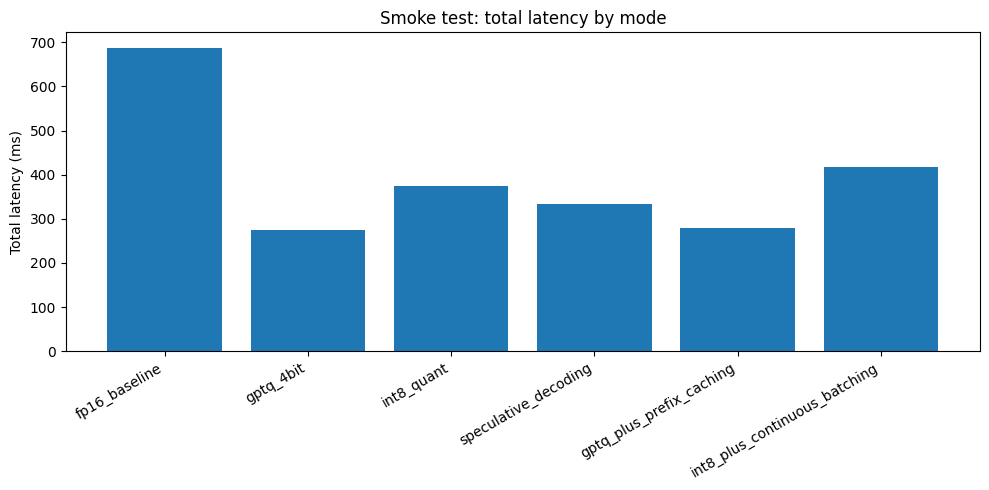

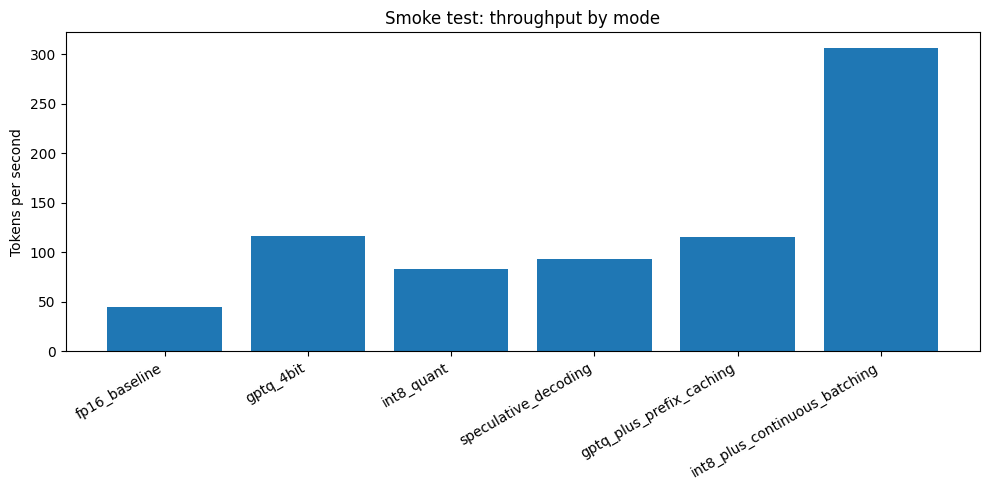

In [10]:
# Plot smoke-test metrics

plot_df = smoke_df.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["mode_name"], plot_df["total_latency_ms"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Total latency (ms)")
plt.title("Smoke test: total latency by mode")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["mode_name"], plot_df["tokens_per_second"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Tokens per second")
plt.title("Smoke test: throughput by mode")
plt.tight_layout()
plt.show()

In [11]:
# Targeted mode-workload tests

targeted_cases = [
    ("fp16_baseline", "short_prompt_short_output"),
    ("fp16_baseline", "long_prompt_long_output"),
    ("gptq_4bit", "short_prompt_short_output"),
    ("gptq_4bit", "short_prompt_long_output"),
    ("int8_quant", "short_prompt_short_output"),
    ("int8_quant", "short_prompt_long_output"),
    ("speculative_decoding", "short_prompt_short_output"),
    ("speculative_decoding", "short_prompt_long_output"),
    ("gptq_plus_prefix_caching", "shared_prefix_chat"),
    ("int8_plus_continuous_batching", "short_prompt_short_output"),
    ("int8_plus_continuous_batching", "long_prompt_short_output"),
]

targeted_results = []

for mode_name, workload_name in targeted_cases:
    print(f"Running targeted test: {mode_name} | {workload_name}")
    r = run_one(mode_name, workload_name, trial_index=0)
    targeted_results.append(summarize_result(r))

targeted_df = pd.DataFrame(targeted_results)
targeted_df

Running targeted test: fp16_baseline | short_prompt_short_output


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


Running targeted test: fp16_baseline | long_prompt_long_output


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


Running targeted test: gptq_4bit | short_prompt_short_output


...

Capturing CUDA graph shapes: 100%|██████████| 3/3 [00:01<00:00,  1.69it/s]


Running targeted test: int8_plus_continuous_batching | long_prompt_short_output


Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


Capturing CUDA graph shapes: 100%|██████████| 3/3 [00:01<00:00,  1.62it/s]


,mode_name,workload_name,success,error,ttft_ms,avg_tbt_ms,total_latency_ms,tokens_per_second,batched_tokens_per_second,output_tokens_generated,...,reserved_gpu_memory_mb,cpu_ram_peak_mb,energy_joules,energy_per_token_j,reference_rouge_l_f1,baseline_similarity_rouge_l_f1,quality_degradation_vs_baseline,num_requests_in_batch,system_condition,notes
0,fp16_baseline,short_prompt_short_output,True,None,24.954783,22.250373,692.465976,44.767542,NaN,31,...,32986.0,7479.664062,120.238042,3.878647,0.264706,None,None,1,baseline,Primary trusted metrics for this run: total la...
1,fp16_baseline,long_prompt_long_output,True,None,111.649070,21.772365,2876.760697,44.494490,NaN,128,...,32986.0,7469.437500,546.522440,4.269707,0.293478,None,None,1,baseline,Primary trusted metrics for this run: total la...
2,gptq_4bit,short_prompt_short_output,True,None,51.326420,7.447745,282.225288,113.384595,NaN,32,...,33210.0,7486.160156,40.875365,1.277355,0.260870,None,None,1,baseline,Primary trusted metrics for this run: total la...
3,gptq_4bit,short_prompt_long_output,True,None,52.000939,7.153912,960.566645,133.254679,NaN,128,...,33230.0,7477.570312,178.383155,1.393618,0.204819,None,None,1,baseline,Primary trusted metrics for this run: total la...
4,int8_quant,short_prompt_short_output,True,None,38.339173,11.489744,383.031492,80.933293,NaN,31,...,33042.0,7488.703125,44.423628,1.433020,0.169014,None,None,1,baseline,Primary trusted metrics for this run: total la...
5,int8_quant,short_prompt_long_output,True,None,38.529206,11.164216,1445.220449,87.875867,NaN,127,...,33042.0,7489.109375,246.086206,1.937687,0.097561,None,None,1,baseline,Primary trusted metrics for this run: total la...
6,speculative_decoding,short_prompt_short_output,True,None,41.354521,9.745188,333.710166,92.894982,NaN,31,...,33100.0,7490.460938,47.763169,1.540747,0.264706,None,None,1,baseline,Primary trusted metrics for this run: total la...
7,speculative_decoding,short_prompt_long_output,True,None,41.055420,10.043961,1306.594447,97.199250,NaN,127,...,33138.0,7491.382812,252.504847,1.988227,0.176471,None,None,1,baseline,Primary trusted metrics for this run: total la...
8,gptq_plus_prefix_caching,shared_prefix_chat_v0,True,None,184.153333,7.397332,650.203238,98.430762,NaN,64,...,33330.0,7513.332031,130.892602,2.045197,0.141593,None,None,1,baseline,Timed follow-up request after priming a shared...
9,int8_plus_continuous_batching,short_prompt_short_output,True,None,63.483281,2.861845,426.953479,299.798471,299.798471,128,...,33142.0,7503.976562,65.766165,0.513798,0.142857,None,None,4,baseline,Primary trusted metrics for this run: total la...


In [12]:
# Grouped comparison by workload

for workload_name in sorted(targeted_df["workload_name"].unique()):
    print("\n" + "=" * 100)
    print("WORKLOAD:", workload_name)
    display(
        targeted_df[targeted_df["workload_name"] == workload_name][[
            "mode_name",
            "success",
            "ttft_ms",
            "avg_tbt_ms",
            "total_latency_ms",
            "tokens_per_second",
            "batched_tokens_per_second",
            "output_tokens_generated",
            "peak_gpu_memory_mb",
            "energy_per_token_j",
            "num_requests_in_batch",
            "reference_rouge_l_f1",
        ]].sort_values("total_latency_ms")
    )


WORKLOAD: long_prompt_long_output


,mode_name,success,ttft_ms,avg_tbt_ms,total_latency_ms,tokens_per_second,batched_tokens_per_second,output_tokens_generated,peak_gpu_memory_mb,energy_per_token_j,num_requests_in_batch,reference_rouge_l_f1
1,fp16_baseline,True,111.64907,21.772365,2876.760697,44.49449,NaN,128,33073.172852,4.269707,1,0.293478



WORKLOAD: long_prompt_short_output


,mode_name,success,ttft_ms,avg_tbt_ms,total_latency_ms,tokens_per_second,batched_tokens_per_second,output_tokens_generated,peak_gpu_memory_mb,energy_per_token_j,num_requests_in_batch,reference_rouge_l_f1
10,int8_plus_continuous_batching,True,289.596968,3.064906,678.85529,188.552703,188.552703,128,33294.238281,1.281619,4,0.180952



WORKLOAD: shared_prefix_chat_v0


,mode_name,success,ttft_ms,avg_tbt_ms,total_latency_ms,tokens_per_second,batched_tokens_per_second,output_tokens_generated,peak_gpu_memory_mb,energy_per_token_j,num_requests_in_batch,reference_rouge_l_f1
8,gptq_plus_prefix_caching,True,184.153333,7.397332,650.203238,98.430762,NaN,64,33203.886719,2.045197,1,0.141593



WORKLOAD: short_prompt_long_output


,mode_name,success,ttft_ms,avg_tbt_ms,total_latency_ms,tokens_per_second,batched_tokens_per_second,output_tokens_generated,peak_gpu_memory_mb,energy_per_token_j,num_requests_in_batch,reference_rouge_l_f1
3,gptq_4bit,True,52.000939,7.153912,960.566645,133.254679,NaN,128,33066.833984,1.393618,1,0.204819
7,speculative_decoding,True,41.055420,10.043961,1306.594447,97.199250,NaN,127,32989.192871,1.988227,1,0.176471
5,int8_quant,True,38.529206,11.164216,1445.220449,87.875867,NaN,127,32957.593750,1.937687,1,0.097561



WORKLOAD: short_prompt_short_output


,mode_name,success,ttft_ms,avg_tbt_ms,total_latency_ms,tokens_per_second,batched_tokens_per_second,output_tokens_generated,peak_gpu_memory_mb,energy_per_token_j,num_requests_in_batch,reference_rouge_l_f1
2,gptq_4bit,True,51.326420,7.447745,282.225288,113.384595,NaN,32,33058.708984,1.277355,1,0.260870
6,speculative_decoding,True,41.354521,9.745188,333.710166,92.894982,NaN,31,32972.942871,1.540747,1,0.264706
4,int8_quant,True,38.339173,11.489744,383.031492,80.933293,NaN,31,32957.593750,1.433020,1,0.169014
9,int8_plus_continuous_batching,True,63.483281,2.861845,426.953479,299.798471,299.798471,128,33059.804199,0.513798,4,0.142857
0,fp16_baseline,True,24.954783,22.250373,692.465976,44.767542,NaN,31,32935.706055,3.878647,1,0.264706


In [13]:
# Notebook mini sweep with multiple trials

NOTEBOOK_SWEEP_CASES = [
    ("fp16_baseline", "short_prompt_short_output"),
    ("fp16_baseline", "short_prompt_long_output"),
    ("gptq_4bit", "short_prompt_short_output"),
    ("gptq_4bit", "short_prompt_long_output"),
    ("int8_quant", "short_prompt_short_output"),
    ("int8_quant", "short_prompt_long_output"),
    ("speculative_decoding", "short_prompt_short_output"),
    ("speculative_decoding", "short_prompt_long_output"),
    ("gptq_plus_prefix_caching", "shared_prefix_chat"),
    ("int8_plus_continuous_batching", "short_prompt_short_output"),
]

NUM_TRIALS = 15

mini_results = []

for mode_name, workload_name in NOTEBOOK_SWEEP_CASES:
    for trial_index in range(NUM_TRIALS):
        print(f"Running: {mode_name} | {workload_name} | trial={trial_index}")
        r = run_one(mode_name, workload_name, trial_index=trial_index)
        mini_results.append(r)

print(f"\nCollected {len(mini_results)} results.")

Running: fp16_baseline | short_prompt_short_output | trial=0


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


Running: fp16_baseline | short_prompt_short_output | trial=1


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


Running: fp16_baseline | short_prompt_short_output | trial=2


...

Capturing CUDA graph shapes: 100%|██████████| 3/3 [00:01<00:00,  1.68it/s]


Running: int8_plus_continuous_batching | short_prompt_short_output | trial=14


Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


Capturing CUDA graph shapes: 100%|██████████| 3/3 [00:01<00:00,  1.67it/s]



Collected 150 results.


In [14]:
# Mini sweep to DataFrame

mini_df = pd.DataFrame([summarize_result(r) for r in mini_results])
mini_df

,mode_name,workload_name,success,error,ttft_ms,avg_tbt_ms,total_latency_ms,tokens_per_second,batched_tokens_per_second,output_tokens_generated,...,reserved_gpu_memory_mb,cpu_ram_peak_mb,energy_joules,energy_per_token_j,reference_rouge_l_f1,baseline_similarity_rouge_l_f1,quality_degradation_vs_baseline,num_requests_in_batch,system_condition,notes
0,fp16_baseline,short_prompt_short_output,True,None,25.536639,22.840401,710.748664,43.615981,NaN,31,...,33126.0,7498.332031,133.025297,4.291139,0.264706,None,None,1,baseline,Primary trusted metrics for this run: total la...
1,fp16_baseline,short_prompt_short_output,True,None,25.928814,22.810919,710.256395,43.646210,NaN,31,...,33126.0,7491.074219,129.038375,4.162528,0.264706,None,None,1,baseline,Primary trusted metrics for this run: total la...
2,fp16_baseline,short_prompt_short_output,True,None,25.610628,22.707206,706.826800,43.857986,NaN,31,...,33126.0,7502.601562,125.792358,4.057818,0.264706,None,None,1,baseline,Primary trusted metrics for this run: total la...
3,fp16_baseline,short_prompt_short_output,True,None,25.821647,23.194965,721.670604,42.955886,NaN,31,...,33126.0,7505.894531,123.217969,3.974773,0.264706,None,None,1,baseline,Primary trusted metrics for this run: total la...
4,fp16_baseline,short_prompt_short_output,True,None,25.684001,22.566029,702.664885,44.117759,NaN,31,...,33126.0,7507.085938,118.962417,3.837497,0.264706,None,None,1,baseline,Primary trusted metrics for this run: total la...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,int8_plus_continuous_batching,short_prompt_short_output,True,None,62.066266,2.793648,416.874559,307.046802,307.046802,128,...,33562.0,7611.496094,54.922433,0.429082,0.142857,None,None,4,baseline,Primary trusted metrics for this run: total la...
146,int8_plus_continuous_batching,short_prompt_short_output,True,None,62.955992,2.780095,416.042769,307.660677,307.660677,128,...,33562.0,7611.648438,69.202227,0.540642,0.142857,None,None,4,baseline,Primary trusted metrics for this run: total la...
147,int8_plus_continuous_batching,short_prompt_short_output,True,None,63.011813,2.789974,417.353418,306.694505,306.694505,128,...,33562.0,7613.148438,52.929521,0.413512,0.142857,None,None,4,baseline,Primary trusted metrics for this run: total la...
148,int8_plus_continuous_batching,short_prompt_short_output,True,None,63.635218,2.775473,416.135280,307.592281,307.592281,128,...,33562.0,7613.257812,64.527742,0.504123,0.142857,None,None,4,baseline,Primary trusted metrics for this run: total la...


In [15]:
# Aggregate mini sweep manually

def mean_or_none(series):
    valid = [x for x in series if pd.notna(x)]
    return sum(valid) / len(valid) if valid else None

agg_rows = []
group_cols = ["mode_name", "workload_name", "system_condition"]

for keys, group in mini_df.groupby(group_cols, dropna=False):
    mode_name, workload_name, system_condition = keys
    agg_rows.append({
        "mode_name": mode_name,
        "workload_name": workload_name,
        "system_condition": system_condition,
        "num_runs": len(group),
        "successes": int(group["success"].sum()) if "success" in group else None,
        "ttft_ms_mean": mean_or_none(group["ttft_ms"]),
        "avg_tbt_ms_mean": mean_or_none(group["avg_tbt_ms"]),
        "total_latency_ms_mean": mean_or_none(group["total_latency_ms"]),
        "tokens_per_second_mean": mean_or_none(group["tokens_per_second"]),
        "batched_tokens_per_second_mean": mean_or_none(group["batched_tokens_per_second"]),
        "peak_gpu_memory_mb_mean": mean_or_none(group["peak_gpu_memory_mb"]),
        "energy_per_token_j_mean": mean_or_none(group["energy_per_token_j"]),
        "reference_rouge_l_f1_mean": mean_or_none(group["reference_rouge_l_f1"]),
    })

mini_agg_df = pd.DataFrame(agg_rows).sort_values(["workload_name", "mode_name"])
mini_agg_df

,mode_name,workload_name,system_condition,num_runs,successes,ttft_ms_mean,avg_tbt_ms_mean,total_latency_ms_mean,tokens_per_second_mean,batched_tokens_per_second_mean,peak_gpu_memory_mb_mean,energy_per_token_j_mean,reference_rouge_l_f1_mean
4,gptq_plus_prefix_caching,shared_prefix_chat_v0,baseline,15,15,124.115888,7.313893,584.910638,109.426368,NaN,33374.511719,1.977822,0.141593
0,fp16_baseline,short_prompt_long_output,baseline,15,15,26.057682,22.557625,2868.318399,44.279797,NaN,32992.581055,3.947374,0.176471
2,gptq_4bit,short_prompt_long_output,baseline,15,15,51.149452,7.059867,947.770090,135.064835,NaN,33242.875651,1.325092,0.201904
6,int8_quant,short_prompt_long_output,baseline,15,15,38.236800,10.916050,1413.659043,89.838953,NaN,33157.242578,1.970552,0.097561
8,speculative_decoding,short_prompt_long_output,baseline,15,15,40.092496,9.781066,1272.506753,99.820684,NaN,33174.442871,1.870364,0.176471
1,fp16_baseline,short_prompt_short_output,baseline,15,15,25.734478,22.994291,715.563217,43.328202,NaN,32992.581055,4.130386,0.264706
3,gptq_4bit,short_prompt_short_output,baseline,15,15,52.376791,7.422180,282.482542,113.368428,NaN,33170.292318,1.021530,0.260870
5,int8_plus_continuous_batching,short_prompt_short_output,baseline,15,15,62.332571,2.774524,414.712000,308.673118,308.673118,33238.554199,0.480314,0.142857
7,int8_quant,short_prompt_short_output,baseline,15,15,37.301796,11.314505,376.736942,82.297410,NaN,33152.593750,1.726127,0.169014
9,speculative_decoding,short_prompt_short_output,baseline,15,15,40.507792,9.542694,326.788603,94.880574,NaN,33168.484538,1.331979,0.264706


In [16]:
# Save notebook mini sweep outputs

timestamp = time.strftime("%Y%m%d_%H%M%S")
mini_json_path = RAW_RESULTS_DIR / f"notebook_mini_results_{timestamp}.json"
mini_csv_path = RAW_RESULTS_DIR / f"notebook_mini_results_{timestamp}.csv"
mini_agg_csv_path = RAW_RESULTS_DIR / f"notebook_mini_aggregates_{timestamp}.csv"

with open(mini_json_path, "w", encoding="utf-8") as f:
    json.dump([r.to_dict() for r in mini_results], f, indent=2)

mini_df.to_csv(mini_csv_path, index=False)
mini_agg_df.to_csv(mini_agg_csv_path, index=False)

print("Saved:")
print(mini_json_path)
print(mini_csv_path)
print(mini_agg_csv_path)

Saved:
/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/notebook_mini_results_20260424_002119.json
/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/notebook_mini_results_20260424_002119.csv
/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/notebook_mini_aggregates_20260424_002119.csv


In [17]:
# Generate full report bundle from notebook mini sweep

report_dir = generate_full_report(
    input_path=mini_json_path,
    output_dir=RAW_RESULTS_DIR / f"notebook_mini_report_{timestamp}",
    quality_metric="auto",
)

print("Report directory:", report_dir)

Report directory: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/notebook_mini_report_20260424_002119


In [18]:
# Inspect generated report artifacts

report_dir = Path(report_dir)

for path in sorted(report_dir.iterdir()):
    print(path.name)

aggregated.csv
aggregated.json
deltas.csv
deltas.json
energy_per_token.png
failure_summary.csv
failure_summary.json
memory_heatmap.png
pareto.json
phase_dominance.csv
phase_dominance.json
phase_dominance.png
prepared_results.json
report.md
ttft_vs_tbt_scatter.png


In [19]:
# Read reporter outputs

aggregated_csv = report_dir / "aggregated.csv"
deltas_csv = report_dir / "deltas.csv"
phase_csv = report_dir / "phase_dominance.csv"
failure_csv = report_dir / "failure_summary.csv"

agg_report_df = pd.read_csv(aggregated_csv) if aggregated_csv.exists() else None
delta_report_df = pd.read_csv(deltas_csv) if deltas_csv.exists() else None
phase_report_df = pd.read_csv(phase_csv) if phase_csv.exists() else None
failure_report_df = pd.read_csv(failure_csv) if failure_csv.exists() else None

print("aggregated.csv")
display(agg_report_df.head() if agg_report_df is not None else None)

print("deltas.csv")
display(delta_report_df.head() if delta_report_df is not None else None)

print("phase_dominance.csv")
display(phase_report_df.head() if phase_report_df is not None else None)

print("failure_summary.csv")
display(failure_report_df.head() if failure_report_df is not None else None)

aggregated.csv


,mode_name,workload_name,workload_cell,system_condition,backend,n,failure_count,failure_rate,num_requests_in_batch_mean,prompt_tokens_target_mean,...,baseline_similarity_rouge_l_f1_median,baseline_similarity_rouge_l_f1_p95,baseline_similarity_rouge_l_f1_min,baseline_similarity_rouge_l_f1_max,quality_degradation_vs_baseline_mean,quality_degradation_vs_baseline_std,quality_degradation_vs_baseline_median,quality_degradation_vs_baseline_p95,quality_degradation_vs_baseline_min,quality_degradation_vs_baseline_max
0,gptq_plus_prefix_caching,shared_prefix_chat_v0,LS,baseline,vllm,15,0,0.0,1.0,1024.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fp16_baseline,short_prompt_long_output,SL,baseline,vllm,15,0,0.0,1.0,128.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,gptq_4bit,short_prompt_long_output,SL,baseline,vllm,15,0,0.0,1.0,128.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,int8_quant,short_prompt_long_output,SL,baseline,vllm,15,0,0.0,1.0,128.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,speculative_decoding,short_prompt_long_output,SL,baseline,vllm,15,0,0.0,1.0,128.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


deltas.csv


,mode_name,workload_name,workload_cell,system_condition,latency_speedup_vs_baseline,throughput_ratio_vs_baseline,energy_ratio_vs_baseline,ttft_ms,avg_tbt_ms,tbt_p95_ms,decode_throughput_tps,energy_per_token_j,peak_gpu_memory_mb,reference_rouge_l_f1,baseline_similarity_rouge_l_f1,quality_degradation_vs_baseline
0,gptq_4bit,short_prompt_long_output,SL,baseline,3.0264,3.0503,0.3357,96.29,-68.70,-66.42,219.50,-66.43,0.76,14.41,NaN,NaN
1,int8_quant,short_prompt_long_output,SL,baseline,2.0290,2.0289,0.4992,46.74,-51.61,-51.61,106.63,-50.08,0.50,-44.72,NaN,NaN
2,speculative_decoding,short_prompt_long_output,SL,baseline,2.2541,2.2543,0.4738,53.86,-56.64,-56.64,130.65,-52.62,0.55,0.00,NaN,NaN
3,gptq_4bit,short_prompt_short_output,SS,baseline,2.5331,2.6165,0.2473,103.53,-67.72,-65.47,209.77,-75.27,0.54,-1.45,NaN,NaN
4,int8_plus_continuous_batching,short_prompt_short_output,SS,baseline,1.7254,7.1241,0.1163,142.21,-87.93,-50.07,708.24,-88.37,0.75,-46.03,NaN,NaN


phase_dominance.csv


,mode_name,workload_name,workload_cell,system_condition,prefill_ms,decode_ms,total_ms,prefill_pct,decode_pct,dominated_by
0,gptq_plus_prefix_caching,shared_prefix_chat_v0,LS,baseline,124.116,460.795,584.911,21.2,78.8,decode
1,fp16_baseline,short_prompt_long_output,SL,baseline,26.058,2842.261,2868.318,0.9,99.1,decode
2,gptq_4bit,short_prompt_long_output,SL,baseline,51.149,896.621,947.770,5.4,94.6,decode
3,int8_quant,short_prompt_long_output,SL,baseline,38.237,1375.422,1413.659,2.7,97.3,decode
4,speculative_decoding,short_prompt_long_output,SL,baseline,40.092,1232.414,1272.507,3.2,96.8,decode


failure_summary.csv


,mode_name,workload_name,workload_cell,system_condition,num_runs,num_failures,failure_rate,most_common_error
0,gptq_plus_prefix_caching,shared_prefix_chat_v0,LS,baseline,15,0,0.0,NaN
1,fp16_baseline,short_prompt_long_output,SL,baseline,15,0,0.0,NaN
2,gptq_4bit,short_prompt_long_output,SL,baseline,15,0,0.0,NaN
3,int8_quant,short_prompt_long_output,SL,baseline,15,0,0.0,NaN
4,speculative_decoding,short_prompt_long_output,SL,baseline,15,0,0.0,NaN


In [20]:
# Full curated benchmark sweep

full_results = run_full_benchmark(
    include_hybrids=True,
    repeated_prefix_variants=2,
    test_profile="controller",
)

print(f"Full run complete. Collected {len(full_results)} results.")

Starting curated large benchmark run
Test profile: controller
Enabled modes: 12
Curated test cases: 25
Trials per pair: 2
Total runs: 50
Per-run logs will be saved under: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/logs


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


[1/50] fp16_baseline            | short_prompt_short_output    | trial=0 | ttft=25.20 ms | lat=689.53 ms | tps=44.96 | J/tok=4.088 | gpu=33171.33 MB


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


[2/50] fp16_baseline            | short_prompt_short_output    | trial=1 | ttft=25.95 ms | lat=681.61 ms | tps=45.48 | J/tok=3.901 | gpu=33171.33 MB


...

[48/50] int8_plus_continuous_batching | short_prompt_long_output     | trial=1 | ttft=58.58 ms | lat=1485.69 ms | tps=344.62 | J/tok=0.538 | gpu=33238.55 MB


Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


[49/50] int8_plus_continuous_batching | long_prompt_short_output     | trial=0 | ttft=311.56 ms | lat=686.97 ms | tps=186.32 | J/tok=1.178 | gpu=33472.99 MB


Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


[50/50] int8_plus_continuous_batching | long_prompt_short_output     | trial=1 | ttft=306.16 ms | lat=681.65 ms | tps=187.78 | J/tok=1.216 | gpu=33472.99 MB

Benchmark sweep complete.
Collected results: 50
Full run complete. Collected 50 results.


In [21]:
# Save full sweep outputs

full_timestamp = time.strftime("%Y%m%d_%H%M%S")

full_json_path = RAW_RESULTS_DIR / f"benchmark_results_{full_timestamp}.json"
full_csv_path = RAW_RESULTS_DIR / f"benchmark_results_{full_timestamp}.csv"
full_summary_csv_path = RAW_RESULTS_DIR / f"benchmark_summary_{full_timestamp}.csv"
full_aggregate_csv_path = RAW_RESULTS_DIR / f"benchmark_aggregates_{full_timestamp}.csv"
full_comparison_csv_path = RAW_RESULTS_DIR / f"benchmark_comparisons_{full_timestamp}.csv"

save_results_json(full_results, full_json_path)
save_results_csv(full_results, full_csv_path)
save_summary_csv(full_results, full_summary_csv_path)

aggregate_rows = build_aggregate_rows(full_results)
comparison_rows = build_comparison_rows(full_results)

save_aggregate_csv(aggregate_rows, full_aggregate_csv_path)
save_aggregate_csv(comparison_rows, full_comparison_csv_path)

print("Saved:")
print(full_json_path)
print(full_csv_path)
print(full_summary_csv_path)
print(full_aggregate_csv_path)
print(full_comparison_csv_path)

Saved:
/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/benchmark_results_20260424_003226.json
/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/benchmark_results_20260424_003226.csv
/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/benchmark_summary_20260424_003226.csv
/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/benchmark_aggregates_20260424_003226.csv
/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/benchmark_comparisons_20260424_003226.csv


In [22]:
# Final report for full sweep

full_report_dir = generate_full_report(
    input_path=full_json_path,
    output_dir=RAW_RESULTS_DIR / f"benchmark_report_{full_timestamp}",
    quality_metric="auto",
)

print("Full report directory:", full_report_dir)

Full report directory: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/benchmark_report_20260424_003226


In [23]:
# Quick notebook summary of winners

full_agg_df = pd.read_csv(full_report_dir / "aggregated.csv")
full_delta_df = pd.read_csv(full_report_dir / "deltas.csv")

display(full_agg_df.sort_values(["workload_name", "total_latency_ms_mean"]))
display(full_delta_df.sort_values(["workload_name", "latency_speedup_vs_baseline"], ascending=[True, False]))

,mode_name,workload_name,workload_cell,system_condition,backend,n,failure_count,failure_rate,num_requests_in_batch_mean,prompt_tokens_target_mean,...,baseline_similarity_rouge_l_f1_median,baseline_similarity_rouge_l_f1_p95,baseline_similarity_rouge_l_f1_min,baseline_similarity_rouge_l_f1_max,quality_degradation_vs_baseline_mean,quality_degradation_vs_baseline_std,quality_degradation_vs_baseline_median,quality_degradation_vs_baseline_p95,quality_degradation_vs_baseline_min,quality_degradation_vs_baseline_max
1,gptq_4bit,long_prompt_long_output,LL,baseline,vllm,2,0,0.0,1.0,1024.0,...,NaN,NaN,NaN,NaN,0.771186,NaN,NaN,NaN,NaN,NaN
2,int8_quant,long_prompt_long_output,LL,baseline,vllm,2,0,0.0,1.0,1024.0,...,NaN,NaN,NaN,NaN,0.163180,NaN,NaN,NaN,NaN,NaN
0,fp16_baseline,long_prompt_long_output,LL,baseline,vllm,2,0,0.0,1.0,1024.0,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
4,gptq_4bit,long_prompt_short_output,LS,baseline,vllm,2,0,0.0,1.0,1024.0,...,NaN,NaN,NaN,NaN,0.814815,NaN,NaN,NaN,NaN,NaN
7,speculative_decoding,long_prompt_short_output,LS,baseline,vllm,2,0,0.0,1.0,1024.0,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
6,int8_quant,long_prompt_short_output,LS,baseline,vllm,2,0,0.0,1.0,1024.0,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
5,int8_plus_continuous_batching,long_prompt_short_output,LS,baseline,vllm,2,0,0.0,4.0,1024.0,...,NaN,NaN,NaN,NaN,0.684211,NaN,NaN,NaN,NaN,NaN
3,fp16_baseline,long_prompt_short_output,LS,baseline,vllm,2,0,0.0,1.0,1024.0,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
9,gptq_4bit,memory_pressure_long_context,LS,mem_pressure_50,vllm,2,0,0.0,1.0,2048.0,...,NaN,NaN,NaN,NaN,0.870690,NaN,NaN,NaN,NaN,NaN
10,int8_quant,memory_pressure_long_context,LS,mem_pressure_50,vllm,2,0,0.0,1.0,2048.0,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN


,mode_name,workload_name,workload_cell,system_condition,latency_speedup_vs_baseline,throughput_ratio_vs_baseline,energy_ratio_vs_baseline,ttft_ms,avg_tbt_ms,tbt_p95_ms,decode_throughput_tps,energy_per_token_j,peak_gpu_memory_mb,reference_rouge_l_f1,baseline_similarity_rouge_l_f1,quality_degradation_vs_baseline
0,gptq_4bit,long_prompt_long_output,LL,baseline,2.6744,2.6736,0.3890,39.96,-66.67,-67.80,199.92,-61.10,0.21,-11.11,-77.12,NaN
1,int8_quant,long_prompt_long_output,LL,baseline,1.9163,1.9158,0.5002,-10.00,-49.31,-50.82,97.22,-49.98,0.02,2.04,-16.32,NaN
2,gptq_4bit,long_prompt_short_output,LS,baseline,2.1136,2.1135,0.3985,30.84,-66.30,-67.01,196.67,-60.15,0.21,-36.36,-81.48,NaN
5,speculative_decoding,long_prompt_short_output,LS,baseline,1.9074,1.9083,0.4219,35.05,-61.03,-62.60,156.62,-57.81,-0.00,0.00,0.00,NaN
4,int8_quant,long_prompt_short_output,LS,baseline,1.7312,1.7312,0.4064,-4.51,-48.39,-48.61,93.74,-59.36,0.02,0.00,0.00,NaN
3,int8_plus_continuous_batching,long_prompt_short_output,LS,baseline,1.1266,4.5060,0.2387,185.95,-86.18,-47.72,606.20,-76.13,0.49,-23.51,-68.42,NaN
6,gptq_4bit,memory_pressure_long_context,LS,mem_pressure_50,2.6002,2.6001,0.4041,23.46,-66.78,-67.80,200.98,-59.59,0.26,-63.65,-87.07,NaN
7,int8_quant,memory_pressure_long_context,LS,mem_pressure_50,1.8983,1.8982,0.4977,-7.70,-49.76,-50.92,99.04,-50.23,0.01,0.00,0.00,NaN
8,gptq_plus_prefix_caching,shared_prefix_chat_v0,LS,baseline,2.4884,2.4882,0.4493,20.32,-65.73,-65.79,191.74,-55.07,0.21,-11.90,-44.72,NaN
9,gptq_plus_prefix_caching,shared_prefix_chat_v1,LS,baseline,2.5264,2.5260,0.4220,17.08,-66.29,-66.04,196.56,-57.80,0.21,-53.74,-77.78,NaN


In [24]:
# Cleanup

import gc
import torch

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Cleanup done.")

Cleanup done.
